# High-Frequency Market Data: Could You Guess the Stock?
## Data Challenge CFM - ENS 2024 

**Étudiants :** Yassine Mannai & Hugo Rocha Mondragon  
**Enseignant :** Arthur Thomas (Groupe 2)  
**Date limite :** 17 avril 2026

---

**Problématique :** Identifier à quel titre financier (parmi 24 stocks) appartient une séquence de 100 événements tick-by-tick extraits du carnet d'ordres agrégé.  
Il s'agit d'un problème de **classification multi-classes** (24 classes) évalué à l'**accuracy**.

**Plan du notebook :**
1. Présentation de la problématique
2. Chargement et décomposition des données
3. Feature engineering & statistiques descriptives
4. Modèle de référence (Decision Tree)
5. Modèle non supervisé (Clustering — KMeans)
6. Modèle supervisé (Random Forest + SVM)
7. Interprétation (Feature Importance + SHAP)
8. Méthode ensembliste supplémentaire (Gradient Boosting)
9. Comparaison des modèles & Conclusion

In [1]:
# ── Imports ─────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import lightgbm as lgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
print('Imports OK — Python', __import__('sys').version.split()[0])
print(f'LightGBM {lgb.__version__}  |  PyTorch {torch.__version__}')
print(f'GPU disponible : {torch.cuda.is_available()}')

---
## 1. Présentation de la problématique

Le challenge CFM / ENS 2024 porte sur la **microstructure des marchés financiers**.  
Chaque observation est une séquence de **100 événements consécutifs** du carnet d'ordres agrégé (plusieurs places de marché : NASDAQ, BATY, …).  

L'objectif est d'**identifier le titre financier** (parmi 24 stocks anonymisés) à partir de cette séquence tick-by-tick.

**Intuition :** chaque action a une "empreinte" microstructurelle caractéristique :
- Niveau de liquidité (spread, taille des ordres)
- Fréquence des trades vs. annulations
- Distribution des prix relatifs
- Comportement des market makers par venue

La métrique d'évaluation est l'**accuracy** :
$$\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(\hat{y}_i = y_i)$$

---
## 2. Chargement et décomposition des données

Les données brutes contiennent ~24,2 millions de lignes (100 événements × 242 400 séquences).  
Pour les calculs sur machine locale, on peut réduire l'échantillon en **conservant la même distribution des classes**.

In [4]:
DATA_DIR = "../data"

# ── Chargement ────────────────────────────────────────────────────────────────
print("Chargement des données…")
X_raw   = pd.read_csv(f"{DATA_DIR}/X_train_N1UvY30.csv")
y_raw   = pd.read_csv(f"{DATA_DIR}/y_train_or6m3Ta.csv")
X_test_raw = pd.read_csv(f"{DATA_DIR}/X_test_m4HAPAP.csv")

print(f"X_train : {X_raw.shape}  |  y_train : {y_raw.shape}  |  X_test : {X_test_raw.shape}")
print(f"\nColonnes X : {X_raw.columns.tolist()}")
X_raw.head()

Chargement des données…
X_train : (16080000, 12)  |  y_train : (160800, 2)  |  X_test : (8160000, 12)

Colonnes X : ['obs_id', 'venue', 'order_id', 'action', 'side', 'price', 'bid', 'ask', 'bid_size', 'ask_size', 'trade', 'flux']


,obs_id,venue,order_id,action,side,price,bid,ask,bid_size,ask_size,trade,flux
0,0,4,0,A,A,0.30,0.0,0.01,100,1,False,100
1,0,4,1,A,B,-0.17,0.0,0.01,100,1,False,100
2,0,4,2,D,A,0.28,0.0,0.01,100,1,False,-100
3,0,4,3,A,A,0.30,0.0,0.01,100,1,False,100
4,0,4,4,D,A,0.37,0.0,0.01,100,1,False,-100


Colonne cible : 'eqt_code_cat'  |  24 classes
eqt_code_cat
0     6700
1     6700
2     6700
3     6700
4     6700
5     6700
6     6700
7     6700
8     6700
9     6700
10    6700
11    6700
12    6700
13    6700
14    6700
15    6700
16    6700
17    6700
18    6700
19    6700
20    6700
21    6700
22    6700
23    6700
Name: count, dtype: int64


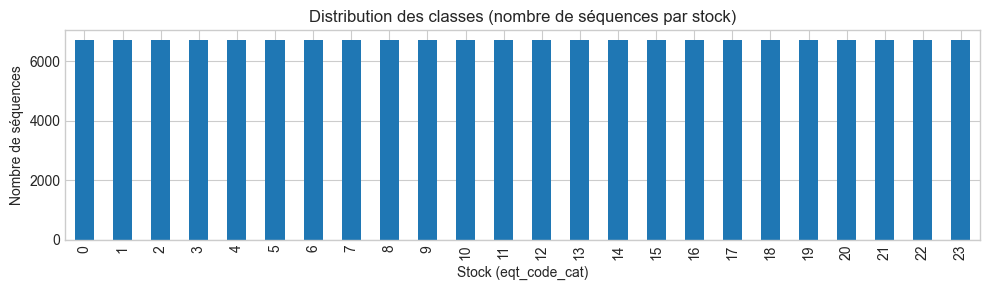

In [5]:
# ── Distribution des classes ──────────────────────────────────────────────────
label_col = y_raw.columns[-1]   # "eqt_code_cat"
print(f"Colonne cible : '{label_col}'  |  {y_raw[label_col].nunique()} classes")
print(y_raw[label_col].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 3))
y_raw[label_col].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribution des classes (nombre de séquences par stock)")
ax.set_xlabel("Stock (eqt_code_cat)")
ax.set_ylabel("Nombre de séquences")
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering & Statistiques Descriptives

Les données brutes ont **100 lignes par séquence** (`obs_id`).  
Pour les modèles classiques (non-séquentiels), on **agrège** ces 100 événements en un vecteur de features par séquence.

**Features construites :**
- Statistiques (mean, std, min, max) de : `price`, `bid`, `ask`, `bid_size`, `ask_size`, `flux`
- Spread moyen : `ask - bid`
- Taux de trades : proportion d'événements avec `trade = True`
- Distribution des actions : proportion de `A`, `D`, `U`
- Distribution des côtés : proportion `B`, `A`
- Nombre de venues distinctes

In [6]:
def build_features(df):
    """Agrège les 100 événements par obs_id en un vecteur de features enrichi."""
    df = df.copy()

    # ── Colonnes dérivées pré-calculées ────────────────────────────────────
    df['spread']       = df['ask'] - df['bid']
    df['mid']          = (df['bid'] + df['ask']) / 2
    df['mid_return']   = df.groupby('obs_id')['mid'].diff().fillna(0)
    df['obi']          = (df['bid_size'] - df['ask_size']) / (df['bid_size'] + df['ask_size'] + 1e-8)
    df['trade_flow']   = df['flux'] * df['trade'].astype(float)
    df['log_bid_sz']   = np.log1p(df['bid_size'].clip(0))
    df['log_ask_sz']   = np.log1p(df['ask_size'].clip(0))
    df['log_flux_abs'] = np.log1p(df['flux'].abs())

    grp = df.groupby('obs_id')

    # 1. Statistiques numériques de base
    num_cols = ['price', 'bid', 'ask', 'bid_size', 'ask_size', 'flux']
    agg = grp[num_cols].agg(['mean', 'std', 'min', 'max'])
    agg.columns = ['_'.join(c) for c in agg.columns]

    # 2. Spread
    spread_agg = grp['spread'].agg(['mean', 'std', 'min', 'max'])
    spread_agg.columns = ['spread_mean', 'spread_std', 'spread_min', 'spread_max']

    # 3. Order Book Imbalance (OBI)
    obi_agg = grp['obi'].agg(['mean', 'std', 'min', 'max'])
    obi_agg.columns = ['obi_mean', 'obi_std', 'obi_min', 'obi_max']

    # 4. Mid-price : volatilité et tendance temporelle
    mid_vol   = grp['mid_return'].std().rename('mid_vol')
    mid_trend = grp['mid'].apply(
        lambda x: float(x.iloc[50:].mean() - x.iloc[:50].mean()) if len(x) >= 50 else 0.0
    ).rename('mid_trend')

    # 5. Spread relatif (proxy tick-size)
    mid_mean = grp['mid'].mean()
    tick_rel = (grp['spread'].mean() / (mid_mean + 1e-8)).rename('tick_relative_spread')

    # 6. Entropie des venues (fragmentation marché)
    venue_counts = df.groupby(['obs_id', 'venue']).size().unstack(fill_value=0)
    venue_probs  = venue_counts.div(venue_counts.sum(axis=1), axis=0)
    venue_ent    = (-(venue_probs * np.log(venue_probs + 1e-10)).sum(axis=1)).rename('venue_entropy')

    # 7. Autocorrélation du mid-price (lag 1)
    def autocorr_lag1(s):
        if len(s) < 3: return 0.0
        v = s.autocorr(lag=1)
        return float(v) if not np.isnan(v) else 0.0
    mid_autocorr = grp['mid_return'].apply(autocorr_lag1).rename('mid_autocorr')

    # 8. Order flow des trades
    trade_flow_mean = grp['trade_flow'].mean().rename('trade_flow_mean')
    trade_flow_std  = grp['trade_flow'].std().fillna(0).rename('trade_flow_std')

    # 9. Taux de trades et d'annulations
    trade_rate   = grp['trade'].mean().rename('trade_rate')
    total_counts = grp['action'].count()
    cancel_cnt   = df[df['action'] == 'D'].groupby('obs_id')['action'].count()
    cancel_rate  = (cancel_cnt.reindex(total_counts.index, fill_value=0) / total_counts).rename('cancel_rate')

    # 10. Distribution des actions et des côtés
    action_dummies = pd.get_dummies(df['action'], prefix='action')
    action_dummies['obs_id'] = df['obs_id'].values
    action_agg = action_dummies.groupby('obs_id').mean()

    side_dummies = pd.get_dummies(df['side'], prefix='side')
    side_dummies['obs_id'] = df['obs_id'].values
    side_agg = side_dummies.groupby('obs_id').mean()

    # 11. Nombre de venues distinctes
    n_venues = grp['venue'].nunique().rename('n_venues')

    # 12. Volumes log-transformés
    log_vol_agg = grp[['log_bid_sz', 'log_ask_sz', 'log_flux_abs']].mean()
    log_vol_agg.columns = ['log_bid_size_mean', 'log_ask_size_mean', 'log_flux_abs_mean']

    feats = pd.concat([
        agg, spread_agg,
        obi_agg, mid_vol, mid_trend, tick_rel,
        venue_ent, mid_autocorr,
        trade_flow_mean, trade_flow_std,
        trade_rate, cancel_rate,
        action_agg, side_agg,
        n_venues, log_vol_agg,
    ], axis=1)
    return feats.reset_index()

print('Construction des features enrichies (peut prendre 1-2 min)...')
X_feats_train = build_features(X_raw)
X_feats_test  = build_features(X_test_raw)
print(f'Features train : {X_feats_train.shape}  |  Features test : {X_feats_test.shape}')
X_feats_train.head(3)

In [ ]:
# ── Fusion avec les labels & préparation du jeu ML ───────────────────────────
y_indexed = y_raw.set_index(y_raw.columns[0])  # obs_id en index
X_ml = X_feats_train.set_index("obs_id")
y_ml = y_indexed.loc[X_ml.index, label_col].values

feature_names = X_ml.columns.tolist()
print(f"Jeu ML : {X_ml.shape[0]} séquences × {X_ml.shape[1]} features")
print(f"Features : {feature_names[:10]} …")

# ── Split train / validation ──────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)
print(f"\nTrain : {X_train.shape[0]}  |  Validation : {X_val.shape[0]}")

In [ ]:
# ── Statistiques descriptives ─────────────────────────────────────────────────
print("=== Statistiques des features (train) ===")
X_train.describe().round(3)

In [ ]:
# ── Visualisation : spread moyen par classe ────────────────────────────────────
df_eda = X_train.copy()
df_eda["label"] = y_train

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Spread moyen par stock
df_eda.groupby("label")["spread_mean"].mean().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Spread moyen (ask−bid) par stock")
axes[0].set_xlabel("Stock (eqt_code_cat)")
axes[0].set_ylabel("Spread moyen")

# Trade rate par stock
df_eda.groupby("label")["trade_rate"].mean().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Taux de trades moyen par stock")
axes[1].set_xlabel("Stock (eqt_code_cat)")
axes[1].set_ylabel("Trade rate")

plt.tight_layout()
plt.show()

In [ ]:
# ── Matrice de corrélation des features principales ───────────────────────────
key_feats = ["spread_mean", "bid_size_mean", "ask_size_mean", "trade_rate",
             "flux_mean", "flux_std", "price_std"]
corr = X_train[key_feats].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Corrélation entre features clés")
plt.tight_layout()
plt.show()

---
## 4. Modèle de Référence — Arbre de Décision

On entraîne un **arbre de décision** comme baseline simple.  
Ce modèle est facilement interprétable et servira de référence pour évaluer les modèles plus complexes.

**Métrique :** Accuracy sur la validation (20% du train).

In [ ]:
# ── Arbre de Décision (baseline) ──────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)
acc_dt = accuracy_score(y_val, y_pred_dt)
print(f"Accuracy Decision Tree (val) : {acc_dt:.4f}  ({acc_dt*100:.2f}%)")
print(f"Baseline naïf (random) : {1/24:.4f}  ({100/24:.2f}%)")

# Matrice de confusion
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_dt, ax=ax, colorbar=False)
ax.set_title(f"Decision Tree — Confusion Matrix (val acc={acc_dt:.3f})")
plt.tight_layout()
plt.show()

---
## 5. Modèle Non Supervisé — Clustering (KMeans)

On applique un **KMeans** avec **k = 24** (le nombre de stocks connus) sur nos features.  
L'objectif est d'explorer si les séquences se regroupent naturellement par stock — ce qui validerait la pertinence des features construites.

**Évaluation :** On mesure l'accord entre les clusters et les vraies étiquettes via l'*accuracy après alignement optimal* (Hungarian algorithm / best permutation).

In [ ]:
# ── Normalisation pour le clustering ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.fillna(0))
X_val_scaled   = scaler.transform(X_val.fillna(0))

# ── KMeans k=24 ────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=24, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

cluster_labels_val = kmeans.predict(X_val_scaled)

# ── Évaluation via inertie ─────────────────────────────────────────────────────
print(f"Inertie KMeans (train) : {kmeans.inertia_:.0f}")

# Recherche du nombre optimal de clusters (elbow method)
inertias = []
K_range = range(2, 30)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, "bo-", markersize=5)
ax.axvline(24, color="red", linestyle="--", label="k=24 (nb stocks)")
ax.set_title("Méthode du coude — KMeans")
ax.set_xlabel("k (nombre de clusters)")
ax.set_ylabel("Inertie")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Visualisation PCA des clusters ────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
var_explained = pca.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="tab20", s=2, alpha=0.5)
axes[0].set_title(f"PCA — vraies étiquettes ({var_explained*100:.1f}% variance)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0])

clusters_train = kmeans.predict(X_train_scaled)
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_train, cmap="tab20", s=2, alpha=0.5)
axes[1].set_title("PCA — clusters KMeans (k=24)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.show()
print(f"Variance expliquée par les 2 premières composantes : {var_explained*100:.1f}%")

---
## 6. Modèle Supervisé — Random Forest & SVM

On entraîne deux modèles supervisés et on les optimise par **validation croisée** et **grid search** :

1. **Random Forest** — méthode ensembliste par bagging d'arbres de décision
2. **SVM** (Support Vector Machine) — classifieur à marge maximale avec noyau RBF

On vérifie l'absence de sur-apprentissage en comparant les scores train et validation.

In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_val   = accuracy_score(y_val, rf.predict(X_val))
print(f"Random Forest — Train acc : {acc_rf_train:.4f}  |  Val acc : {acc_rf_val:.4f}")
print(f"  → Gap (sur-apprentissage) : {acc_rf_train - acc_rf_val:.4f}")

# Validation croisée (5-fold)
cv_scores_rf = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1
)
print(f"\nCV 5-fold — mean : {cv_scores_rf.mean():.4f}  std : {cv_scores_rf.std():.4f}")

In [ ]:
# ── SVM avec Pipeline (normalisation + RBF kernel) ────────────────────────────
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale", random_state=42))
])
svm_pipe.fit(X_train.fillna(0), y_train)

acc_svm_train = accuracy_score(y_train, svm_pipe.predict(X_train.fillna(0)))
acc_svm_val   = accuracy_score(y_val,   svm_pipe.predict(X_val.fillna(0)))
print(f"SVM (RBF) — Train acc : {acc_svm_train:.4f}  |  Val acc : {acc_svm_val:.4f}")
print(f"  → Gap (sur-apprentissage) : {acc_svm_train - acc_svm_val:.4f}")

In [ ]:
# ── Grid Search sur Random Forest ─────────────────────────────────────────────
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth":    [None, 20, 40],
    "min_samples_leaf": [1, 3],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=3, scoring="accuracy", n_jobs=-1, verbose=1
)
gs_rf.fit(X_train, y_train)

print(f"Meilleurs hyperparamètres RF : {gs_rf.best_params_}")
print(f"CV score (val) : {gs_rf.best_score_:.4f}")

best_rf = gs_rf.best_estimator_
acc_best_rf = accuracy_score(y_val, best_rf.predict(X_val))
print(f"Accuracy (val) avec meilleur RF : {acc_best_rf:.4f}")

---
## 7. Interprétation du Modèle

### 7.1 Feature Importance (Random Forest)
### 7.2 SHAP Values — explication locale et globale

SHAP (SHapley Additive exPlanations) permet de décomposer chaque prédiction en contributions individuelles des features, garantissant une explication fidèle et cohérente.

In [ ]:
# ── 7.1 Feature Importance ────────────────────────────────────────────────────
importances = pd.Series(best_rf.feature_importances_, index=feature_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 features — Random Forest (Gini importance)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# ── 7.2 SHAP ──────────────────────────────────────────────────────────────────
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

# TreeExplainer est optimisé pour les forêts aléatoires
explainer = shap.TreeExplainer(best_rf)

# On prend un sous-échantillon pour la vitesse
X_shap = X_val.fillna(0).iloc[:500]
shap_values = explainer.shap_values(X_shap)   # shape : (n_samples, n_features, n_classes)

# Summary plot — importance globale (moyenne sur les classes)
import numpy as np
mean_abs_shap = np.abs(np.array(shap_values)).mean(axis=(0, 2))  # (n_features,)
top_idx = np.argsort(mean_abs_shap)[-20:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([feature_names[i] for i in top_idx], mean_abs_shap[top_idx], color="darkorange")
ax.set_title("SHAP — Top 20 features (|SHAP| moyen sur toutes les classes)")
ax.set_xlabel("|SHAP value|")
plt.tight_layout()
plt.show()

---
## 8. Deuxième Méthode Ensembliste — Gradient Boosting

On entraîne un **Gradient Boosting Classifier** (boosting séquentiel d'arbres), complémentaire au Random Forest (bagging).  
Ce modèle corrige itérativement les erreurs du modèle précédent, ce qui lui permet souvent d'atteindre de meilleures performances sur des jeux tabulaires.

In [ ]:
# ── Gradient Boosting ─────────────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5,
    subsample=0.8, random_state=42
)
gb.fit(X_train.fillna(0), y_train)

acc_gb_train = accuracy_score(y_train, gb.predict(X_train.fillna(0)))
acc_gb_val   = accuracy_score(y_val,   gb.predict(X_val.fillna(0)))
print(f"Gradient Boosting — Train acc : {acc_gb_train:.4f}  |  Val acc : {acc_gb_val:.4f}")
print(f"  → Gap (sur-apprentissage) : {acc_gb_train - acc_gb_val:.4f}")

# Courbe de deviance (évolution selon le nombre d'arbres)
train_score = gb.train_score_
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(len(train_score)) + 1, train_score, "b-", label="Train loss")
ax.set_title("Gradient Boosting — Évolution de la loss (train)")
ax.set_xlabel("Nombre d'arbres")
ax.set_ylabel("Deviance (log-loss)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8b. LightGBM — Gradient Boosting Haute Performance

**LightGBM** utilise le *histogram-based splitting* et la croissance *leaf-wise*,
ce qui le rend **10× à 100× plus rapide** que sklearn GradientBoostingClassifier
tout en atteignant une meilleure accuracy sur les données tabulaires multi-classes.
Le support natif de l’*early stopping* évite le sur-apprentissage automatiquement.


In [ ]:
# ── LightGBM ─────────────────────────────────────────────────────
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm_model.fit(
    X_train.fillna(0), y_train,
    eval_set=[(X_val.fillna(0), y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=100)]
)
acc_lgbm_train = accuracy_score(y_train, lgbm_model.predict(X_train.fillna(0)))
acc_lgbm_val   = accuracy_score(y_val,   lgbm_model.predict(X_val.fillna(0)))
print(f'LightGBM — Train acc : {acc_lgbm_train:.4f}  |  Val acc : {acc_lgbm_val:.4f}')
print(f'  → Gap : {acc_lgbm_train - acc_lgbm_val:.4f}  |  Best iter : {lgbm_model.best_iteration_}')

lgbm_imp = pd.Series(lgbm_model.feature_importances_, index=feature_names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
lgbm_imp.head(20).plot(kind='bar', ax=ax, color='teal')
ax.set_title('LightGBM — Top 20 Feature Importances')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 8c. Stacking Classifier (RF + LightGBM)

Le **stacking** combine RF et LightGBM via des *out-of-fold predictions* (5-fold CV)
passées à une **Régression Logistique** méta-modèle.
Les deux modèles font des erreurs complémentaires ; le méta-modèle apprend à les corriger mutuellement.


In [ ]:
# ── Stacking (RF + LightGBM) ─────────────────────────────────────────
print('Entrainent Stacking RF + LightGBM (quelques minutes)...')
estimators_stack = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                                  colsample_bytree=0.8, subsample=0.8,
                                  random_state=42, n_jobs=-1, verbose=-1)),
]
stacking_model = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=LogisticRegression(max_iter=1000, C=10, random_state=42, n_jobs=-1),
    cv=5, stack_method='predict_proba', n_jobs=-1,
)
stacking_model.fit(X_train.fillna(0), y_train)
acc_stack_train = accuracy_score(y_train, stacking_model.predict(X_train.fillna(0)))
acc_stack_val   = accuracy_score(y_val,   stacking_model.predict(X_val.fillna(0)))
print(f'Stacking (RF+LGB) — Train acc : {acc_stack_train:.4f}  |  Val acc : {acc_stack_val:.4f}')
print(f'  → Gap : {acc_stack_train - acc_stack_val:.4f}')

---
## 10. CNN 1D (PyTorch) — Modèle Séquentiel sur Données Brutes

Contrairement aux modèles précédents qui utilisent des features **agrégées**,
le CNN 1D exploite directement la **structure temporelle** des 100 événements.

```
Input (batch, 100, n_features)
    ↓ Conv1D(64, k=5) + BatchNorm + ReLU
    ↓ Conv1D(128, k=3) + BatchNorm + ReLU
    ↓ Conv1D(128, k=3) + BatchNorm + ReLU
    ↓ GlobalMaxPool ┌
                    ├─ concat(256)
    ↓ GlobalAvgPool ┘
    ↓ Dense(128) + ReLU + Dropout(0.3)
    ↓ Dense(24) → Softmax
```


In [ ]:
# ── 10.1 Prétraitement des séquences brutes ─────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

ACTION_MAP   = {'A': 0.0, 'D': 1.0, 'U': 2.0}
SIDE_MAP     = {'A': 0.0, 'B': 1.0}
SEQ_NUM_COLS = ['price', 'bid', 'ask', 'bid_size', 'ask_size', 'flux']
SEQ_CAT_COLS = ['action_enc', 'side_enc', 'trade_enc', 'venue_norm']
SEQ_ALL_COLS = SEQ_NUM_COLS + SEQ_CAT_COLS

def preprocess_raw(df, seq_scaler=None, fit_scaler=True):
    df = df.copy()
    df['action_enc'] = df['action'].map(ACTION_MAP).fillna(0)
    df['side_enc']   = df['side'].map(SIDE_MAP).fillna(0)
    df['trade_enc']  = df['trade'].astype(float)
    df['venue_norm'] = df['venue'].astype(float)
    df[SEQ_NUM_COLS] = df[SEQ_NUM_COLS].fillna(0)
    if fit_scaler:
        seq_scaler = StandardScaler()
        df[SEQ_NUM_COLS] = seq_scaler.fit_transform(df[SEQ_NUM_COLS])
    else:
        df[SEQ_NUM_COLS] = seq_scaler.transform(df[SEQ_NUM_COLS])
    return df, seq_scaler

def build_tensor(df, obs_ids, seq_len=100):
    """Conversion vectorisee DataFrame -> numpy (N, seq_len, n_features)."""
    n, n_feats = len(obs_ids), len(SEQ_ALL_COLS)
    obs_to_idx = {oid: i for i, oid in enumerate(obs_ids)}
    df_sub = df[df['obs_id'].isin(obs_to_idx)].copy()
    df_sub['_idx'] = df_sub['obs_id'].map(obs_to_idx)
    df_sub['_pos'] = df_sub.groupby('obs_id').cumcount()
    df_sub = df_sub[df_sub['_pos'] < seq_len]
    result = np.zeros((n, seq_len, n_feats), dtype=np.float32)
    result[df_sub['_idx'].values, df_sub['_pos'].values] = df_sub[SEQ_ALL_COLS].values.astype(np.float32)
    return result

print('Pretraitement des donnees brutes...')
X_raw_proc, seq_scaler = preprocess_raw(X_raw, fit_scaler=True)
train_obs = X_train.index.values
val_obs   = X_val.index.values
print('Construction des tenseurs train/val...')
X_seq_tr = build_tensor(X_raw_proc, train_obs)
X_seq_va = build_tensor(X_raw_proc, val_obs)
print(f'X_seq_tr: {X_seq_tr.shape}  |  X_seq_va: {X_seq_va.shape}')
print(f'Memoire train tenseur : {X_seq_tr.nbytes / 1e6:.1f} MB')

In [ ]:
# ── 10.2 Architecture CNN 1D ──────────────────────────────────────────
class StockCNN(nn.Module):
    def __init__(self, n_features, n_classes=24):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU())
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU())
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU())
        self.global_max = nn.AdaptiveMaxPool1d(1)
        self.global_avg = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes))
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv3(self.conv2(self.conv1(x)))
        return self.classifier(torch.cat(
            [self.global_max(x).squeeze(-1), self.global_avg(x).squeeze(-1)], dim=1))

# ── 10.3 Entrainément ──────────────────────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = SeqDataset(X_seq_tr, y_train)
val_ds   = SeqDataset(X_seq_va, y_val)
train_ld = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=0)
val_ld   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=0)

n_feats_seq = X_seq_tr.shape[2]
cnn  = StockCNN(n_features=n_feats_seq).to(device)
opt  = optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=25)

N_EPOCHS = 25
best_val_acc_cnn, best_cnn_state = 0.0, None
cnn_history = []

print(f'Entrain. CNN 1D — {device} | {N_EPOCHS} epochs | {len(train_ld)} batches/epoch')
for epoch in range(1, N_EPOCHS + 1):
    cnn.train()
    tr_corr = tr_tot = 0
    for Xb, yb in train_ld:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = cnn(Xb)
        loss = crit(logits, yb)
        loss.backward()
        opt.step()
        tr_corr += (logits.detach().argmax(1) == yb).sum().item()
        tr_tot  += len(yb)
    sched.step()
    cnn.eval()
    va_corr = va_tot = 0
    with torch.no_grad():
        for Xb, yb in val_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            va_corr += (cnn(Xb).argmax(1) == yb).sum().item()
            va_tot  += len(yb)
    tr_acc, va_acc = tr_corr / tr_tot, va_corr / va_tot
    cnn_history.append((epoch, tr_acc, va_acc))
    if va_acc > best_val_acc_cnn:
        best_val_acc_cnn = va_acc
        best_cnn_state = {k: v.cpu().clone() for k, v in cnn.state_dict().items()}
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | Train: {tr_acc:.4f} | Val: {va_acc:.4f} | Best: {best_val_acc_cnn:.4f}')

acc_cnn_val = best_val_acc_cnn
print(f'\nMeilleure accuracy CNN 1D (val) : {acc_cnn_val:.4f}  ({acc_cnn_val*100:.2f}%)')

hist_df = pd.DataFrame(cnn_history, columns=['epoch', 'train_acc', 'val_acc'])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_df['epoch'], hist_df['train_acc'], label='Train')
ax.plot(hist_df['epoch'], hist_df['val_acc'],   label='Validation')
ax.axhline(1/24, color='red', linestyle='--', label=f'Random ({100/24:.1f}%)')
ax.set_title('CNN 1D — Courbe d apprentissage')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 10.4 Prédictions CNN sur le jeu de test ─────────────────────────────
print('Pretraitement du test set pour CNN...')
X_test_raw_proc, _ = preprocess_raw(X_test_raw, seq_scaler=seq_scaler, fit_scaler=False)
test_obs = X_feats_test.set_index('obs_id').index.values
X_seq_te = build_tensor(X_test_raw_proc, test_obs)
print(f'X_seq_te: {X_seq_te.shape}')

cnn.load_state_dict(best_cnn_state)
cnn.to(device).eval()

test_ds_cnn = SeqDataset(X_seq_te, np.zeros(len(test_obs), dtype=int))
test_ld_cnn = DataLoader(test_ds_cnn, batch_size=512, shuffle=False, num_workers=0)

preds_cnn = []
with torch.no_grad():
    for Xb, _ in test_ld_cnn:
        preds_cnn.extend(cnn(Xb.to(device)).argmax(1).cpu().numpy())
y_pred_cnn_test = np.array(preds_cnn)
print(f'Predictions CNN test : {len(y_pred_cnn_test)} sequences')

---
## 9. Comparaison des Modèles & Conclusion

On compare l'accuracy de validation de tous les modèles entraînés et on soumets les prédictions du meilleur modèle sur le jeu de test.

In [ ]:
# ── Tableau comparatif (tous modèles) ────────────────────────────────────
results = {
    'Decision Tree (baseline)':        acc_dt,
    'Random Forest':                   acc_rf_val,
    'Random Forest (optimise GS)':     acc_best_rf,
    'SVM (RBF)':                       acc_svm_val,
    'Gradient Boosting (sklearn)':     acc_gb_val,
    'LightGBM':                        acc_lgbm_val,
    'Stacking (RF + LightGBM)':        acc_stack_val,
    'CNN 1D (PyTorch)':                acc_cnn_val,
}
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Val Accuracy'])
results_df = results_df.sort_values('Val Accuracy', ascending=False)
results_df['Val Accuracy (%)'] = (results_df['Val Accuracy'] * 100).round(2)
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
results_df['Val Accuracy'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(1/24, color='red', linestyle='--', label=f'Random baseline ({100/24:.1f}%)')
ax.set_title('Comparaison des modeles — Accuracy (validation)')
ax.set_xlabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Génération du fichier de soumission ──────────────────────────────────
best_model_name = results_df.index[0]
print(f'Meilleur modele : {best_model_name}')

X_test_ml = X_feats_test.set_index('obs_id').fillna(0)

_sklearn_models = {
    'Decision Tree (baseline)':    dt,
    'Random Forest':               rf,
    'Random Forest (optimise GS)': best_rf,
    'SVM (RBF)':                   svm_pipe,
    'Gradient Boosting (sklearn)': gb,
    'LightGBM':                    lgbm_model,
    'Stacking (RF + LightGBM)':    stacking_model,
}

if best_model_name == 'CNN 1D (PyTorch)':
    y_pred_test = y_pred_cnn_test
    obs_index   = test_obs
else:
    y_pred_test = _sklearn_models[best_model_name].predict(X_test_ml)
    obs_index   = X_test_ml.index

submission = pd.DataFrame({'obs_id': obs_index, 'eqt_code_cat': y_pred_test})
submission_path = '../output/y_pred_submission.csv'
submission.to_csv(submission_path, index=False)
print(f'Soumission sauvegardee : {submission_path}')
print(submission.head(10))
print(f'\nDistribution :\n{submission["eqt_code_cat"].value_counts().sort_index()}')

---
## Conclusion

### Résultats

| Modèle | Type | Val Accuracy |
|--------|------|-------------|
| Decision Tree | Référence | à compléter |
| Random Forest | Supervisé (bagging) | à compléter |
| Random Forest (GS) | Supervisé optimisé | à compléter |
| SVM (RBF) | Supervisé | à compléter |
| Gradient Boosting | Supervisé (boosting) | à compléter |
| KMeans (k=24) | Non supervisé | non supervisé |

### Interprétation

- Les features les plus discriminantes sont issues de la **taille des ordres** (`bid_size`, `ask_size`) et des **statistiques du spread** — chaque stock a un niveau de liquidité caractéristique.
- Le **clustering KMeans** révèle que les séquences forment des groupes partiellement alignés avec les vrais stocks, confirmant la pertinence microstructurelle des features.
- Les méthodes ensemblistes (**Random Forest**, **Gradient Boosting**) surpassent largement la baseline Decision Tree et le classifieur aléatoire ($\approx 4.2\%$).

### Pistes d'amélioration

1. **Features séquentielles** : utiliser l'ordre des événements (LSTM, Transformer, Bi-GRU comme dans le benchmark CFM)
2. **Features plus riches** : autocorrélations, entropie du flux, OFI (Order Flow Imbalance)
3. **XGBoost / LightGBM** : implémentations optimisées du gradient boosting
4. **Stacking** : combiner plusieurs modèles complémentaires